# Evaluación temporal externa de los modelos

## 1. Protocolo de evaluación previamente definido

Este notebook constituye la fase final del procedimiento de modelización. Todas las decisiones relativas a selección de variables, algoritmos, hiperparámetros y preprocesamiento se realizaron utilizando exclusivamente el conjunto de desarrollo formado por las temporadas 2009–2019 y 2022–2023.

La temporada 2024 permaneció excluida de dichas decisiones y se utiliza en este notebook únicamente como periodo de evaluación temporal externa.

La variable objetivo es `porcentaje_juegos_ganados`, por lo que el problema se formula como una tarea de regresión. La métrica principal será el error absoluto medio (MAE), complementado mediante RMSE y \(R^2\).

XGBoost se mantiene como modelo predictivo principal al haber obtenido el menor MAE medio durante la validación temporal interna. HistGradientBoosting y LightGBM, cuyos resultados fueron prácticamente equivalentes durante el desarrollo, se utilizarán únicamente como análisis de robustez frente a la elección del algoritmo dentro de la familia principal de 365 días.

En la familia de 365 días se evaluarán las especificaciones BASE, PRINCIPAL y AMPLIADA. La comparación BASE–PRINCIPAL permitirá estudiar la aportación de las cinco dimensiones principales de carga competitiva, mientras que la comparación PRINCIPAL–AMPLIADA permitirá evaluar la contribución adicional de `diff_torneos_365d`.

La familia de 180 días se utilizará como análisis de robustez frente al horizonte temporal y se evaluará mediante XGBoost, manteniendo igualmente las especificaciones BASE, PRINCIPAL y AMPLIADA.

Las métricas correspondientes a las familias de 365 y 180 días no se compararán directamente entre sí, debido a que ambas se construyeron sobre muestras ligeramente diferentes.

Los resultados obtenidos en 2024 no se utilizarán para seleccionar nuevamente algoritmos, modificar hiperparámetros, incorporar o eliminar variables, introducir nuevas transformaciones ni alterar las especificaciones previamente definidas. Cualquier resultado favorable, neutro o desfavorable será interpretado como evidencia sobre la capacidad de generalización del procedimiento ya fijado.

## 2. Carga de la configuración congelada

La evaluación temporal externa debe reproducir exactamente las decisiones fijadas durante la fase de desarrollo. Para ello, se cargan los archivos de configuración exportados al cerrar `07_desarrollo_modelos_validacion_temporal.ipynb`.

Estos archivos contienen el protocolo general de evaluación, los conjuntos de predictores, las variables de carga competitiva y los hiperparámetros previamente seleccionados para los modelos finales.

En esta etapa se recupera la configuración fijada durante el desarrollo antes de acceder a los conjuntos de desarrollo y evaluación temporal. No se accede todavía a los conjuntos de desarrollo ni a la temporada 2024.

In [1]:
import pandas as pd


configuracion_evaluacion = pd.read_csv(
    "configuracion_evaluacion_final.csv"
)

predictores_finales = pd.read_csv(
    "predictores_modelado_final.csv"
)

cargas_finales = pd.read_csv(
    "cargas_modelado_final.csv"
)

hiperparametros_finales = pd.read_csv(
    "hiperparametros_modelos_finales.csv"
)
configuracion_dict = (
    configuracion_evaluacion
    .set_index("clave")["valor"]
    .to_dict()
)


## 3. Carga de los conjuntos de desarrollo y evaluación temporal

Una vez verificada y congelada la configuración del procedimiento, se cargan los conjuntos correspondientes a las familias de 365 y 180 días.

Para cada familia se dispone de un conjunto de desarrollo, utilizado para el ajuste definitivo de los modelos, y de un conjunto correspondiente exclusivamente a la temporada 2024, reservado para la evaluación temporal externa.

En este paso únicamente se cargan los datos y se comprueba su estructura básica. No se ajusta ningún modelo ni se calcula todavía ninguna métrica predictiva.

La fecha del torneo se convierte explícitamente a formato temporal para preservar una representación cronológica consistente durante las comprobaciones posteriores.

In [2]:
df_desarrollo_365d = pd.read_csv(
    configuracion_dict["dataset_desarrollo_365d"],
    low_memory=False
)

df_evaluacion_365d = pd.read_csv(
    configuracion_dict["dataset_evaluacion_365d"],
    low_memory=False
)

df_desarrollo_180d = pd.read_csv(
    configuracion_dict["dataset_desarrollo_180d"],
    low_memory=False
)

df_evaluacion_180d = pd.read_csv(
    configuracion_dict["dataset_evaluacion_180d"],
    low_memory=False
)


datasets_modelado = {
    "desarrollo_365d": df_desarrollo_365d,
    "evaluacion_365d": df_evaluacion_365d,
    "desarrollo_180d": df_desarrollo_180d,
    "evaluacion_180d": df_evaluacion_180d
}



for df in datasets_modelado.values():
    df["fecha_torneo"] = pd.to_datetime(
        df["fecha_torneo"],
        errors="raise"
    )

anio_evaluacion = int(
    configuracion_dict["periodo_evaluacion_final"]
)

anios_desarrollo_esperados = (
    set(range(2009, 2020))
    | {2022, 2023}
)

for familia, df_desarrollo, df_evaluacion in [
    (
        "365d",
        df_desarrollo_365d,
        df_evaluacion_365d
    ),
    (
        "180d",
        df_desarrollo_180d,
        df_evaluacion_180d
    )
]:

    anios_desarrollo = set(
        df_desarrollo["match_year"]
        .dropna()
        .astype(int)
        .unique()
    )

    anios_evaluacion = set(
        df_evaluacion["match_year"]
        .dropna()
        .astype(int)
        .unique()
    )

    assert anios_desarrollo == anios_desarrollo_esperados

    assert anios_evaluacion == {
        anio_evaluacion
    }

    assert set(
        df_desarrollo["_id_partido"]
    ).isdisjoint(
        set(df_evaluacion["_id_partido"])
    )

    assert (
        df_desarrollo
        .groupby("_id_partido")
        .size()
        .eq(2)
        .all()
    )

    assert (
        df_evaluacion
        .groupby("_id_partido")
        .size()
        .eq(2)
        .all()
    )

for nombre, df in datasets_modelado.items():

    print(f"\n{nombre}")

    print("Dimensión:", df.shape)

    print(
        "Partidos:",
        df["_id_partido"].nunique()
    )

    print(
        "Años:",
        sorted(
            df["match_year"]
            .dropna()
            .astype(int)
            .unique()
        )
    )


desarrollo_365d
Dimensión: (73250, 56)
Partidos: 36625
Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023)]

evaluacion_365d
Dimensión: (5912, 56)
Partidos: 2956
Años: [np.int64(2024)]

desarrollo_180d
Dimensión: (73450, 56)
Partidos: 36725
Años: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023)]

evaluacion_180d
Dimensión: (5912, 56)
Partidos: 2956
Años: [np.int64(2024)]


## 4. Reconstrucción de las especificaciones y modelos congelados

Una vez validada la separación entre desarrollo y evaluación temporal, se reconstruyen los conjuntos de predictores y las configuraciones de los modelos fijados durante la fase de desarrollo.

Los hiperparámetros se recuperan directamente de los archivos exportados, evitando redefinirlos manualmente. Cada modelo se integra en un `Pipeline` junto con una imputación por mediana, que posteriormente será ajustada exclusivamente utilizando el conjunto de desarrollo.

En esta etapa únicamente se preparan las especificaciones. Todavía no se realiza ningún ajuste ni se generan predicciones sobre 2024.

In [3]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


def convertir_valor(valor, tipo):
    if tipo == "bool":
        return str(valor).lower() == "true"
    if tipo == "int":
        return int(float(valor))
    if tipo == "float":
        return float(valor)
    return str(valor)


def obtener_hiperparametros(algoritmo):
    filas = hiperparametros_finales[
        hiperparametros_finales["algoritmo"] == algoritmo
    ]

    return {
        fila["parametro"]: convertir_valor(
            fila["valor"],
            fila["tipo"]
        )
        for _, fila in filas.iterrows()
    }


def obtener_predictores(familia, especificacion):
    return (
        predictores_finales.loc[
            (predictores_finales["familia"] == familia)
            & (predictores_finales["especificacion"] == especificacion)
        ]
        .sort_values("orden")["predictor"]
        .tolist()
    )


constructores_modelos = {
    "XGBRegressor": XGBRegressor,
    "HistGradientBoostingRegressor": HistGradientBoostingRegressor,
    "LGBMRegressor": LGBMRegressor
}


hiperparametros_por_modelo = {
    algoritmo: obtener_hiperparametros(algoritmo)
    for algoritmo in constructores_modelos
}


def crear_pipeline(algoritmo):
    modelo = constructores_modelos[algoritmo](
        **hiperparametros_por_modelo[algoritmo]
    )

    return Pipeline(
        [
            (
                "imputador",
                SimpleImputer(
                    strategy=configuracion_dict["imputacion"]
                )
            ),
            ("modelo", modelo)
        ]
    )


predictores_por_especificacion = {
    (familia, especificacion): obtener_predictores(
        familia,
        especificacion
    )
    for familia in ["365d", "180d"]
    for especificacion in ["base", "principal", "ampliado"]
}


print("Modelos y especificaciones reconstruidos correctamente.")

Modelos y especificaciones reconstruidos correctamente.


## 5. Definición de los ajustes finales

Antes de entrenar los modelos se define explícitamente el conjunto de ajustes que serán evaluados.

En la familia principal de 365 días se utilizan XGBoost, HistGradientBoosting y LightGBM para comprobar si las conclusiones sobre la incorporación de carga competitiva son robustas frente a la arquitectura predictiva. Para cada algoritmo se mantienen las especificaciones BASE, PRINCIPAL y AMPLIADA.

La familia de 180 días se utiliza exclusivamente como análisis de robustez frente al horizonte temporal y se evalúa mediante XGBoost con las mismas tres especificaciones.

Todos los modelos utilizan los hiperparámetros y predictores fijados durante el desarrollo. Esta definición no podrá modificarse posteriormente en función de los resultados obtenidos en 2024.

In [4]:
variable_objetivo = configuracion_dict["variable_objetivo"]


ajustes_finales = [
    # Familia principal de 365 días
    ("365d", "base", "XGBRegressor"),
    ("365d", "principal", "XGBRegressor"),
    ("365d", "ampliado", "XGBRegressor"),

    ("365d", "base", "HistGradientBoostingRegressor"),
    ("365d", "principal", "HistGradientBoostingRegressor"),
    ("365d", "ampliado", "HistGradientBoostingRegressor"),

    ("365d", "base", "LGBMRegressor"),
    ("365d", "principal", "LGBMRegressor"),
    ("365d", "ampliado", "LGBMRegressor"),

    # Robustez del horizonte temporal
    ("180d", "base", "XGBRegressor"),
    ("180d", "principal", "XGBRegressor"),
    ("180d", "ampliado", "XGBRegressor"),
]

## 6. Entrenamiento definitivo y generación de predicciones

Una vez fijados los modelos, los hiperparámetros y los conjuntos de predictores, cada especificación se ajusta utilizando la totalidad de su correspondiente muestra de desarrollo.

El preprocesamiento permanece integrado dentro del `Pipeline`, de modo que la imputación por mediana se estima exclusivamente a partir de los datos de desarrollo antes de transformar las observaciones correspondientes a 2024.

Tras el ajuste se generan las predicciones sobre la evaluación temporal externa. En esta etapa no se calculan todavía métricas ni se comparan los resultados obtenidos, evitando utilizar el comportamiento observado en 2024 para modificar cualquier decisión previamente fijada.

In [5]:
modelos_ajustados = {}
predicciones_finales = {}


datasets_por_familia = {
    "365d": (
        df_desarrollo_365d,
        df_evaluacion_365d
    ),
    "180d": (
        df_desarrollo_180d,
        df_evaluacion_180d
    )
}


for familia, especificacion, algoritmo in ajustes_finales:

    df_desarrollo, df_evaluacion = (
        datasets_por_familia[familia]
    )

    predictores = predictores_por_especificacion[
        (familia, especificacion)
    ]

    X_desarrollo = df_desarrollo[predictores]
    y_desarrollo = df_desarrollo[variable_objetivo]

    X_evaluacion = df_evaluacion[predictores]

    pipeline = crear_pipeline(algoritmo)

    pipeline.fit(
        X_desarrollo,
        y_desarrollo
    )

    predicciones = pipeline.predict(
        X_evaluacion
    )

    clave = (
        familia,
        especificacion,
        algoritmo
    )

    modelos_ajustados[clave] = pipeline
    predicciones_finales[clave] = predicciones

    print(
        f"Completado: "
        f"{familia} | "
        f"{especificacion} | "
        f"{algoritmo}"
    )

Completado: 365d | base | XGBRegressor
Completado: 365d | principal | XGBRegressor
Completado: 365d | ampliado | XGBRegressor
Completado: 365d | base | HistGradientBoostingRegressor
Completado: 365d | principal | HistGradientBoostingRegressor
Completado: 365d | ampliado | HistGradientBoostingRegressor
Completado: 365d | base | LGBMRegressor
Completado: 365d | principal | LGBMRegressor
Completado: 365d | ampliado | LGBMRegressor
Completado: 180d | base | XGBRegressor
Completado: 180d | principal | XGBRegressor
Completado: 180d | ampliado | XGBRegressor


## 7. Evaluación temporal externa sobre 2024

Una vez generadas todas las predicciones correspondientes a las especificaciones previamente fijadas, se evalúa su capacidad de generalización sobre la temporada 2024.

El MAE se mantiene como métrica principal, al cuantificar directamente la desviación media absoluta entre el porcentaje de juegos ganados observado y el estimado por el modelo. Como medidas complementarias se calculan RMSE y \(R^2\).

Las métricas se obtienen simultáneamente para todos los ajustes definidos antes de acceder a los resultados de 2024. Las comparaciones entre especificaciones se realizarán únicamente dentro de una misma familia temporal y, para el análisis de robustez algorítmica, dentro de una misma arquitectura predictiva.

In [6]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


resultados_evaluacion = []


for familia, especificacion, algoritmo in ajustes_finales:

    _, df_evaluacion = datasets_por_familia[familia]

    y_real = df_evaluacion[variable_objetivo]

    clave = (
        familia,
        especificacion,
        algoritmo
    )

    y_pred = predicciones_finales[clave]

    mae = mean_absolute_error(
        y_real,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real,
            y_pred
        )
    )

    r2 = r2_score(
        y_real,
        y_pred
    )

    resultados_evaluacion.append(
        {
            "familia": familia,
            "algoritmo": algoritmo,
            "especificacion": especificacion,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        }
    )


resultados_evaluacion = pd.DataFrame(
    resultados_evaluacion
)


orden_especificaciones = {
    "base": 0,
    "principal": 1,
    "ampliado": 2
}

resultados_evaluacion["orden"] = (
    resultados_evaluacion["especificacion"]
    .map(orden_especificaciones)
)

resultados_evaluacion = (
    resultados_evaluacion
    .sort_values(
        [
            "familia",
            "algoritmo",
            "orden"
        ]
    )
    .drop(columns="orden")
    .reset_index(drop=True)
)


display(
    resultados_evaluacion.round(6)
)

,familia,algoritmo,especificacion,MAE,RMSE,R2
0,180d,XGBRegressor,base,0.099877,0.126815,0.121360
1,180d,XGBRegressor,principal,0.098932,0.126132,0.130804
2,180d,XGBRegressor,ampliado,0.098805,0.125915,0.133785
3,365d,HistGradientBoostingRegressor,base,0.100003,0.126819,0.121308
4,365d,HistGradientBoostingRegressor,principal,0.099142,0.126170,0.130277
5,365d,HistGradientBoostingRegressor,ampliado,0.098701,0.125540,0.138936
6,365d,LGBMRegressor,base,0.099959,0.126851,0.120866
7,365d,LGBMRegressor,principal,0.099198,0.126370,0.127511
8,365d,LGBMRegressor,ampliado,0.098581,0.125547,0.138845
9,365d,XGBRegressor,base,0.099902,0.126825,0.121227


### Magnitud de la mejora aportada por las variables de carga

Para cuantificar la aportación predictiva incremental de las variables de carga se calculan las diferencias de MAE entre las especificaciones previamente definidas.

Se consideran tres contrastes: BASE frente a PRINCIPAL, que evalúa conjuntamente las cinco dimensiones principales de carga; PRINCIPAL frente a AMPLIADO, que cuantifica la aportación adicional de la frecuencia de participación; y BASE frente a AMPLIADO, que resume la mejora total de la especificación completa.

Además de la diferencia absoluta de MAE, se calcula su reducción relativa respecto a la especificación de referencia. Estas magnitudes permiten cuantificar la relevancia predictiva práctica de las mejoras observadas. Su estabilidad frente a variaciones en la composición de la muestra se examinará posteriormente mediante el bootstrap pareado a nivel de partido.

In [7]:
contrastes = []

for (familia, algoritmo), grupo in (
    resultados_evaluacion
    .groupby(["familia", "algoritmo"])
):

    mae = (
        grupo
        .set_index("especificacion")["MAE"]
        .to_dict()
    )

    comparaciones = [
        ("base", "principal"),
        ("principal", "ampliado"),
        ("base", "ampliado")
    ]

    for referencia, comparado in comparaciones:

        mejora_absoluta = (
            mae[referencia] - mae[comparado]
        )

        mejora_relativa = (
            mejora_absoluta
            / mae[referencia]
            * 100
        )

        contrastes.append(
            {
                "familia": familia,
                "algoritmo": algoritmo,
                "comparacion": (
                    f"{referencia} → {comparado}"
                ),
                "MAE_referencia": mae[referencia],
                "MAE_comparado": mae[comparado],
                "mejora_MAE": mejora_absoluta,
                "mejora_relativa_pct": mejora_relativa
            }
        )


contrastes_evaluacion = pd.DataFrame(
    contrastes
)

display(
    contrastes_evaluacion.round(
        {
            "MAE_referencia": 6,
            "MAE_comparado": 6,
            "mejora_MAE": 6,
            "mejora_relativa_pct": 3
        }
    )
)

,familia,algoritmo,comparacion,MAE_referencia,MAE_comparado,mejora_MAE,mejora_relativa_pct
0,180d,XGBRegressor,base → principal,0.099877,0.098932,0.000946,0.947
1,180d,XGBRegressor,principal → ampliado,0.098932,0.098805,0.000127,0.128
2,180d,XGBRegressor,base → ampliado,0.099877,0.098805,0.001072,1.074
3,365d,HistGradientBoostingRegressor,base → principal,0.100003,0.099142,0.000861,0.861
4,365d,HistGradientBoostingRegressor,principal → ampliado,0.099142,0.098701,0.000441,0.445
5,365d,HistGradientBoostingRegressor,base → ampliado,0.100003,0.098701,0.001302,1.302
6,365d,LGBMRegressor,base → principal,0.099959,0.099198,0.000761,0.762
7,365d,LGBMRegressor,principal → ampliado,0.099198,0.098581,0.000617,0.622
8,365d,LGBMRegressor,base → ampliado,0.099959,0.098581,0.001379,1.379
9,365d,XGBRegressor,base → principal,0.099902,0.099051,0.000851,0.851


### Representación gráfica de los resultados de la evaluación temporal externa

Con el objetivo de complementar la presentación tabular de los resultados obtenidos sobre la temporada 2024, se representa gráficamente la mejora de las especificaciones PRINCIPAL y AMPLIADA respecto al modelo BASE dentro de la familia principal de 365 días.

La primera figura muestra la reducción relativa del MAE respecto al modelo BASE para XGBoost, HistGradientBoosting y LightGBM. La segunda representa, para los mismos algoritmos, el incremento de \(R^2\) respecto al modelo BASE, expresado en puntos porcentuales.

Estas representaciones tienen una finalidad expositiva y permiten comparar visualmente la magnitud de la mejora dentro de cada algoritmo. Los valores exactos de MAE, RMSE y \(R^2\) se mantienen recogidos en la tabla de resultados de la evaluación temporal externa.

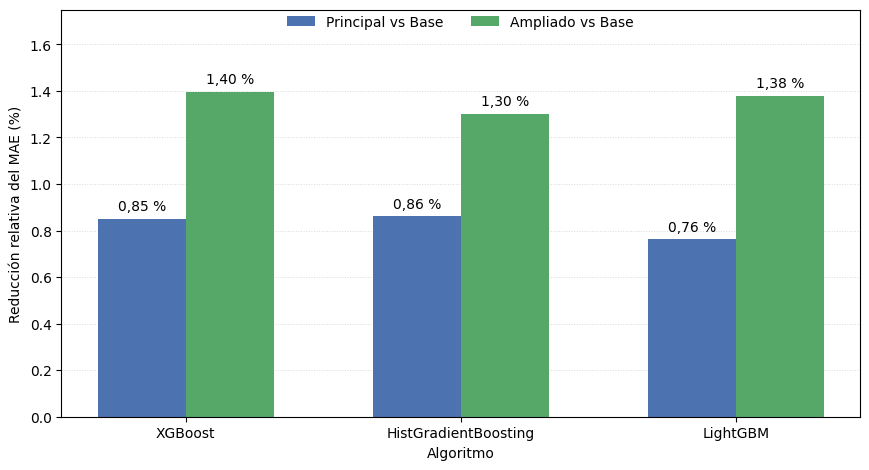

In [8]:
# ============================================================
# FIGURA — REDUCCIÓN RELATIVA DEL MAE RESPECTO AL BASE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def formato_es(valor, decimales):
    return f"{valor:.{decimales}f}".replace(".", ",")


# ------------------------------------------------------------
# Resultados de la familia principal de 365 días
# ------------------------------------------------------------

df_fig = resultados_evaluacion[
    resultados_evaluacion["familia"].eq("365d")
].copy()

alg_order = [
    "XGBRegressor",
    "HistGradientBoostingRegressor",
    "LGBMRegressor"
]

alg_labels = [
    "XGBoost",
    "HistGradientBoosting",
    "LightGBM"
]

spec_order = [
    "base",
    "principal",
    "ampliado"
]


pivot_mae = (
    df_fig
    .pivot(
        index="algoritmo",
        columns="especificacion",
        values="MAE"
    )
    .loc[alg_order, spec_order]
)


# ------------------------------------------------------------
# Reducción relativa respecto al modelo Base
# ------------------------------------------------------------

mejora_mae = pd.DataFrame(
    {
        "Principal": (
            (pivot_mae["base"] - pivot_mae["principal"])
            / pivot_mae["base"]
            * 100
        ),
        "Ampliado": (
            (pivot_mae["base"] - pivot_mae["ampliado"])
            / pivot_mae["base"]
            * 100
        )
    },
    index=alg_order
)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

x = np.arange(len(alg_order))
width = 0.32

fig_mae, ax = plt.subplots(figsize=(8.8, 4.8))

bars_principal = ax.bar(
    x - width / 2,
    mejora_mae["Principal"],
    width,
    label="Principal vs Base",
    color="#4C72B0"
)

bars_ampliado = ax.bar(
    x + width / 2,
    mejora_mae["Ampliado"],
    width,
    label="Ampliado vs Base",
    color="#55A868"
)


# ------------------------------------------------------------
# Valores sobre las barras
# ------------------------------------------------------------

for bars in [bars_principal, bars_ampliado]:
    for bar in bars:

        valor = bar.get_height()

        ax.annotate(
            f"{formato_es(valor, 2)} %",
            (
                bar.get_x() + bar.get_width() / 2,
                valor
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )


# ------------------------------------------------------------
# Formato final
# ------------------------------------------------------------

ax.set_ylabel(
    "Reducción relativa del MAE (%)"
)

ax.set_xlabel("Algoritmo")

ax.set_xticks(x)
ax.set_xticklabels(alg_labels)

ax.set_ylim(
    0,
    mejora_mae.to_numpy().max() * 1.25
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45
)

ax.set_axisbelow(True)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.show()




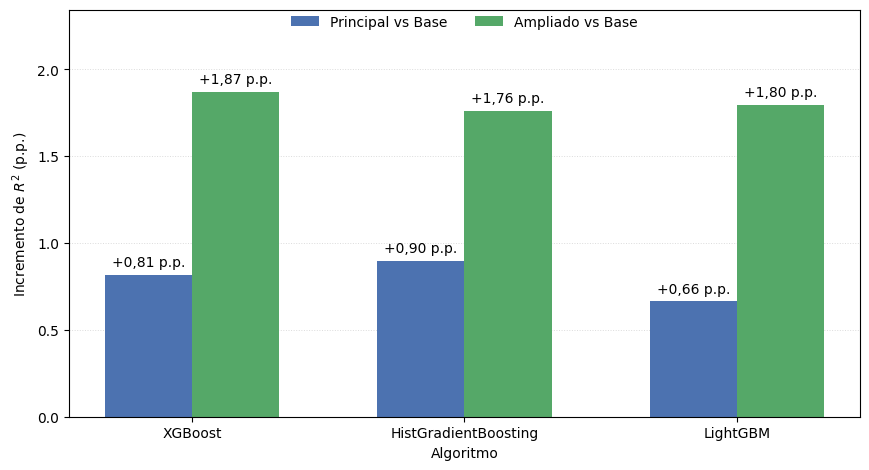

In [9]:
# ============================================================
# FIGURA — INCREMENTO DE R² RESPECTO AL BASE
# ============================================================

pivot_r2 = (
    df_fig
    .pivot(
        index="algoritmo",
        columns="especificacion",
        values="R2"
    )
    .loc[alg_order, spec_order]
)

# Conversión de R² a porcentaje
pivot_r2_pct = pivot_r2 * 100


# ------------------------------------------------------------
# Incremento respecto al modelo Base en puntos porcentuales
# ------------------------------------------------------------

mejora_r2 = pd.DataFrame(
    {
        "Principal": (
            pivot_r2_pct["principal"]
            - pivot_r2_pct["base"]
        ),
        "Ampliado": (
            pivot_r2_pct["ampliado"]
            - pivot_r2_pct["base"]
        )
    },
    index=alg_order
)


# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

x = np.arange(len(alg_order))
width = 0.32

fig_r2, ax = plt.subplots(figsize=(8.8, 4.8))

bars_principal = ax.bar(
    x - width / 2,
    mejora_r2["Principal"],
    width,
    label="Principal vs Base",
    color="#4C72B0"
)

bars_ampliado = ax.bar(
    x + width / 2,
    mejora_r2["Ampliado"],
    width,
    label="Ampliado vs Base",
    color="#55A868"
)


# ------------------------------------------------------------
# Valores sobre las barras
# ------------------------------------------------------------

for bars in [bars_principal, bars_ampliado]:
    for bar in bars:

        valor = bar.get_height()

        ax.annotate(
            f"+{formato_es(valor, 2)} p.p.",
            (
                bar.get_x() + bar.get_width() / 2,
                valor
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10
        )


# ------------------------------------------------------------
# Formato final
# ------------------------------------------------------------

ax.set_ylabel(
    r"Incremento de $R^2$ (p.p.)"
)

ax.set_xlabel("Algoritmo")

ax.set_xticks(x)
ax.set_xticklabels(alg_labels)

ax.set_ylim(
    0,
    mejora_r2.to_numpy().max() * 1.25
)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45
)

ax.set_axisbelow(True)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout()
plt.show()




### Incertidumbre de la mejora predictiva en la evaluación temporal externa

La diferencia de MAE observada entre dos especificaciones constituye una estimación obtenida sobre los partidos disputados en 2024. Para cuantificar su variabilidad se utiliza un bootstrap pareado a nivel de partido.

La unidad de remuestreo es `_id_partido`, manteniendo conjuntamente las dos observaciones recíprocas correspondientes a cada encuentro. De este modo se respeta la dependencia estructural existente entre ambas perspectivas jugador–rival.

El análisis se centra en los tres contrastes del modelo principal XGBoost de 365 días y, como comprobación adicional de robustez temporal, en la comparación BASE–AMPLIADO de la familia de 180 días.

Los intervalos obtenidos se interpretan como medidas descriptivas de incertidumbre condicionadas a los modelos ya entrenados y no como intervalos que incorporen toda la incertidumbre asociada al proceso previo de selección y optimización.

In [10]:
rng = np.random.default_rng(42)

contrastes_bootstrap = [
    ("365d", "XGBRegressor", "base", "principal"),
    ("365d", "XGBRegressor", "principal", "ampliado"),
    ("365d", "XGBRegressor", "base", "ampliado"),
    ("180d", "XGBRegressor", "base", "ampliado"),
]

n_bootstrap = 5000
resultados_bootstrap = []


for familia, algoritmo, referencia, comparado in contrastes_bootstrap:

    _, df_evaluacion = datasets_por_familia[familia]

    ids_partido = (
        df_evaluacion["_id_partido"]
        .drop_duplicates()
        .to_numpy()
    )

    y_real = df_evaluacion[variable_objetivo].to_numpy()

    pred_ref = predicciones_finales[
        (familia, referencia, algoritmo)
    ]

    pred_comp = predicciones_finales[
        (familia, comparado, algoritmo)
    ]

    error_ref = np.abs(y_real - pred_ref)
    error_comp = np.abs(y_real - pred_comp)

    diferencias_por_partido = (
        pd.DataFrame({
            "_id_partido": df_evaluacion["_id_partido"].to_numpy(),
            "diferencia_error": error_ref - error_comp
        })
        .groupby("_id_partido")["diferencia_error"]
        .mean()
    )

    diferencias_bootstrap = np.empty(n_bootstrap)

    for b in range(n_bootstrap):

        muestra_ids = rng.choice(
            ids_partido,
            size=len(ids_partido),
            replace=True
        )

        diferencias_bootstrap[b] = (
            diferencias_por_partido
            .loc[muestra_ids]
            .mean()
        )

    mejora_observada = diferencias_por_partido.mean()

    ic_inferior, ic_superior = np.percentile(
        diferencias_bootstrap,
        [2.5, 97.5]
    )

    resultados_bootstrap.append({
        "familia": familia,
        "algoritmo": algoritmo,
        "comparacion": f"{referencia} → {comparado}",
        "mejora_MAE": mejora_observada,
        "IC95_inferior": ic_inferior,
        "IC95_superior": ic_superior,
        "proporcion_bootstrap_positiva": (
            diferencias_bootstrap > 0
        ).mean()
    })


resultados_bootstrap = pd.DataFrame(
    resultados_bootstrap
)

display(
    resultados_bootstrap.round(6)
)

,familia,algoritmo,comparacion,mejora_MAE,IC95_inferior,IC95_superior,proporcion_bootstrap_positiva
0,365d,XGBRegressor,base → principal,0.000851,0.000145,0.001573,0.9902
1,365d,XGBRegressor,principal → ampliado,0.000545,0.000023,0.001050,0.9788
2,365d,XGBRegressor,base → ampliado,0.001395,0.000560,0.002225,0.9992
3,180d,XGBRegressor,base → ampliado,0.001072,0.000236,0.001860,0.9940


### Representación de la incertidumbre asociada a la mejora predictiva

Para visualizar la incertidumbre de las mejoras observadas en la evaluación temporal
externa de 2024, se representan las estimaciones puntuales de la reducción del MAE
junto con sus intervalos bootstrap percentiles del 95 %.

La mejora se define como:

$$
\Delta_{\mathrm{mejora}}
=
MAE_{\mathrm{referencia}}
-
MAE_{\mathrm{modelo\ comparado}}.
$$

Por tanto, valores positivos indican que la especificación comparada presenta un MAE
inferior al modelo utilizado como referencia. La línea vertical situada en cero representa
la ausencia de mejora. Un intervalo situado completamente a la derecha de esta referencia
indica que la reducción del error se mantiene positiva dentro del intervalo bootstrap
obtenido.

La figura utiliza directamente los resultados previamente calculados mediante 5.000
remuestreos a nivel de partido y no introduce nuevas estimaciones.

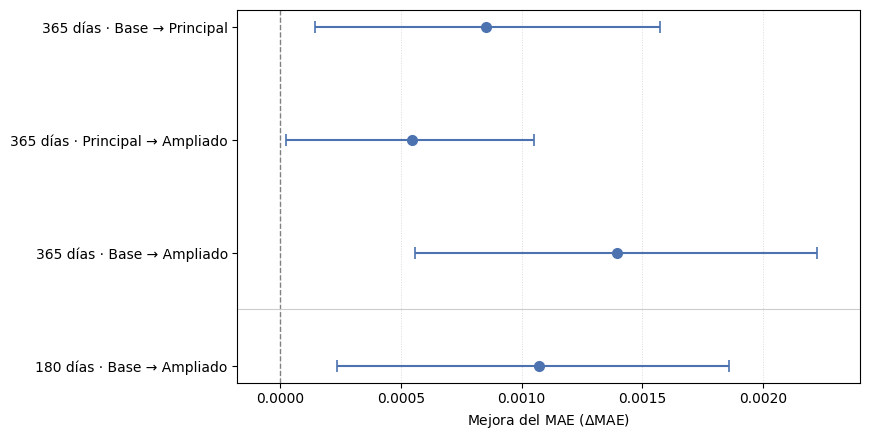

In [11]:
# ============================================================
# FIGURA — INCERTIDUMBRE BOOTSTRAP DE LA MEJORA DEL MAE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# ------------------------------------------------------------
# 1. Preparación de los resultados ya calculados
# ------------------------------------------------------------

df_boot = resultados_bootstrap.copy()

orden = [
    ("365d", "base → principal"),
    ("365d", "principal → ampliado"),
    ("365d", "base → ampliado"),
    ("180d", "base → ampliado")
]

df_boot["orden"] = df_boot.apply(
    lambda fila: orden.index(
        (fila["familia"], fila["comparacion"])
    ),
    axis=1
)

df_boot = (
    df_boot
    .sort_values("orden")
    .reset_index(drop=True)
)

etiquetas = {
    ("365d", "base → principal"):
        "365 días · Base → Principal",

    ("365d", "principal → ampliado"):
        "365 días · Principal → Ampliado",

    ("365d", "base → ampliado"):
        "365 días · Base → Ampliado",

    ("180d", "base → ampliado"):
        "180 días · Base → Ampliado"
}

df_boot["etiqueta"] = df_boot.apply(
    lambda fila: etiquetas[
        (fila["familia"], fila["comparacion"])
    ],
    axis=1
)


# ------------------------------------------------------------
# 2. Estimaciones puntuales e intervalos bootstrap del 95 %
# ------------------------------------------------------------

estimacion = df_boot["mejora_MAE"].to_numpy()
inferior = df_boot["IC95_inferior"].to_numpy()
superior = df_boot["IC95_superior"].to_numpy()

error_izquierdo = estimacion - inferior
error_derecho = superior - estimacion

y = np.arange(len(df_boot))


# ------------------------------------------------------------
# 3. Representación gráfica
# ------------------------------------------------------------

fig_bootstrap, ax = plt.subplots(
    figsize=(8.8, 4.5)
)

ax.errorbar(
    estimacion,
    y,
    xerr=[
        error_izquierdo,
        error_derecho
    ],
    fmt="o",
    color="#4C72B0",
    markersize=7,
    elinewidth=1.5,
    capsize=4,
    capthick=1.2
)


# ------------------------------------------------------------
# 4. Línea de referencia: ausencia de mejora
# ------------------------------------------------------------

ax.axvline(
    x=0,
    color="gray",
    linestyle="--",
    linewidth=1
)


# ------------------------------------------------------------
# 5. Separación entre análisis principal y robustez de 180 días
# ------------------------------------------------------------

ax.axhline(
    y=2.5,
    color="0.80",
    linestyle="-",
    linewidth=0.8
)


# ------------------------------------------------------------
# 6. Etiquetas de los contrastes
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(
    df_boot["etiqueta"],
    fontsize=10
)

ax.invert_yaxis()


# ------------------------------------------------------------
# 7. Ejes
# ------------------------------------------------------------

ax.set_xlabel(r"Mejora del MAE ($\Delta$MAE)")

ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, pos:
        f"{valor:.4f}".replace(".", ".")
    )
)


# ------------------------------------------------------------
# 8. Escala horizontal
# ------------------------------------------------------------

limite_superior = df_boot["IC95_superior"].max()

margen = limite_superior * 0.08

ax.set_xlim(
    -margen,
    limite_superior + margen
)


# ------------------------------------------------------------
# 9. Rejilla y formato final
# ------------------------------------------------------------

ax.grid(
    axis="x",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()




### Resultado del análisis de incertidumbre

El bootstrap pareado a nivel de partido respaldó la estabilidad de las mejoras observadas en la evaluación temporal externa.

En XGBoost con la familia de 365 días, tanto la incorporación del núcleo principal de variables de carga como la comparación entre el modelo BASE y la especificación AMPLIADA presentaron intervalos bootstrap del 95 % completamente positivos. La mejora BASE–AMPLIADO fue positiva en prácticamente todas las réplicas realizadas.

La incorporación adicional de `diff_torneos_365d` también mostró una mejora favorable, aunque con un intervalo más próximo a cero, por lo que su contribución individual debe interpretarse con mayor cautela que la aportación conjunta del núcleo de carga.

La especificación ampliada de 180 días mostró igualmente un intervalo completamente positivo frente al correspondiente modelo BASE, respaldando la estabilidad de la conclusión al modificar el horizonte temporal.

Estos resultados se interpretan como evidencia descriptiva de estabilidad condicionada a los modelos previamente entrenados. No representan un contraste causal ni incorporan toda la incertidumbre asociada al proceso previo de selección de variables y optimización.

## 8. Diagnóstico de las predicciones del modelo principal

Antes de abordar la interpretabilidad del modelo se revisan dos propiedades de las predicciones obtenidas por la especificación AMPLIADA del modelo principal XGBoost-365d.

En primer lugar, se comprueba el rango de las predicciones, dado que `porcentaje_juegos_ganados` está definido entre 0 y 1 mientras que XGBoost no impone matemáticamente esta restricción sobre su salida.

En segundo lugar, se estudia la reciprocidad de las predicciones correspondientes a las dos perspectivas de un mismo partido. Como los porcentajes de juegos ganados de ambos jugadores son complementarios, una representación perfectamente simétrica produciría predicciones cuya suma fuese igual a 1.

Estas comprobaciones tienen carácter diagnóstico. No se aplicará clipping ni simetrización posterior en función de sus resultados.

In [12]:
clave_modelo_principal = (
    "365d",
    "ampliado",
    "XGBRegressor"
)

pred_principal = predicciones_finales[
    clave_modelo_principal
]

df_diagnostico = df_evaluacion_365d[
    ["_id_partido"]
].copy()

df_diagnostico["prediccion"] = pred_principal


predicciones_fuera_rango = (
    (df_diagnostico["prediccion"] < 0)
    | (df_diagnostico["prediccion"] > 1)
).sum()


suma_por_partido = (
    df_diagnostico
    .groupby("_id_partido")["prediccion"]
    .sum()
)

desviacion_reciprocidad = (
    suma_por_partido - 1
).abs()


print(
    "Predicción mínima:",
    round(df_diagnostico["prediccion"].min(), 6)
)

print(
    "Predicción máxima:",
    round(df_diagnostico["prediccion"].max(), 6)
)

print(
    "Predicciones fuera de [0, 1]:",
    predicciones_fuera_rango
)

print(
    "Desviación media de reciprocidad:",
    round(desviacion_reciprocidad.mean(), 6)
)

print(
    "Desviación máxima de reciprocidad:",
    round(desviacion_reciprocidad.max(), 6)
)

Predicción mínima: 0.32215
Predicción máxima: 0.681196
Predicciones fuera de [0, 1]: 0
Desviación media de reciprocidad: 0.003377
Desviación máxima de reciprocidad: 0.019296


### Coherencia entre valores observados y predicciones del modelo final

Las comprobaciones anteriores muestran que todas las predicciones de la especificación ampliada XGBoost-365d permanecen dentro del intervalo teórico \([0,1]\), por lo que no resulta necesario aplicar truncamiento. La desviación absoluta media respecto a la reciprocidad perfecta entre las dos perspectivas de cada partido es de aproximadamente 0,0034 y la desviación máxima de 0,0193.

Por tanto, aunque el modelo no impone explícitamente una restricción de simetría, las predicciones presentan una elevada coherencia entre las dos representaciones recíprocas de cada encuentro. No se aplica ninguna corrección o simetrización posterior.

Como comprobación visual complementaria de la evaluación temporal externa, se representa la relación entre los valores observados del porcentaje de juegos ganados y las predicciones obtenidas por la especificación ampliada XGBoost-365d en 2024.

Debido al elevado número de observaciones, se utiliza una representación hexagonal de densidad (`hexbin`). Cada celda agrupa las observaciones situadas en una misma región del plano y su intensidad representa el número de casos contenidos en ella. De este modo, se utilizan todas las observaciones disponibles evitando la sobreimpresión que produciría un gráfico de dispersión convencional.

La recta de identidad $y=x$ representa el caso de predicción perfecta. La figura permite examinar visualmente la relación entre valores observados y predichos, la dispersión de las predicciones y su comportamiento en las zonas extremas de la variable objetivo. Esta representación complementa, pero no sustituye, las métricas MAE, RMSE y $R^2$ utilizadas para evaluar cuantitativamente el modelo.

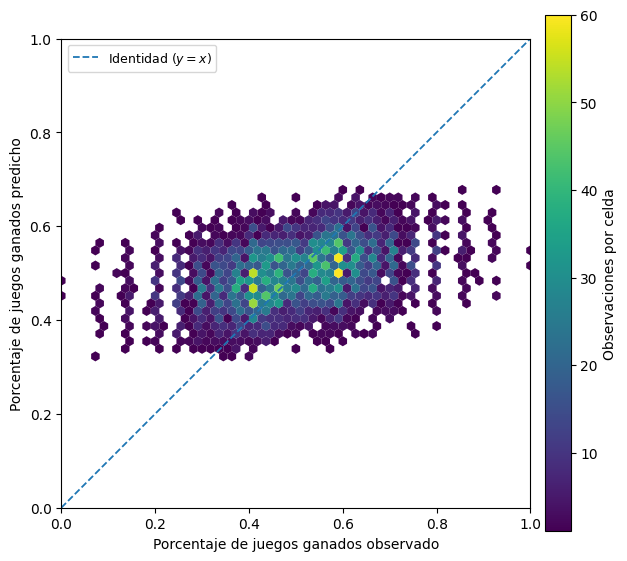

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Datos definitivos de la evaluación temporal externa de 2024
y_real_plot = (
    df_evaluacion_365d[variable_objetivo]
    .to_numpy()
)

y_pred_plot = np.asarray(pred_principal)

assert y_real_plot.shape == y_pred_plot.shape

fig_hex_final, ax = plt.subplots(figsize=(6.5, 5.8))

hb = ax.hexbin(
    y_real_plot,
    y_pred_plot,
    gridsize=55,
    extent=(0, 1, 0, 1),
    mincnt=1,
    linewidths=0
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.3,
    label=r"Identidad ($y=x$)"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Porcentaje de juegos ganados observado")
ax.set_ylabel("Porcentaje de juegos ganados predicho")

ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_yticks(np.arange(0, 1.01, 0.2))

ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=9
)

cbar = fig_hex_final.colorbar(
    hb,
    ax=ax,
    pad=0.025
)

cbar.set_label("Observaciones por celda")

plt.tight_layout()
plt.show()

## 9. Importancia de variables del modelo final

Una vez evaluada la capacidad de generalización del modelo, se estudia qué predictores intervienen con mayor intensidad en la especificación final de XGBoost correspondiente a la familia de 365 días.

Como primera medida descriptiva se utiliza la importancia basada en ganancia (`gain`) proporcionada por XGBoost. Esta medida resume cuánto contribuyen, en promedio, las divisiones asociadas a cada predictor a mejorar la función objetivo durante la construcción de los árboles.

El análisis se realiza únicamente con finalidad interpretativa. Las importancias obtenidas no se utilizarán para seleccionar nuevamente variables ni para modificar el modelo después de haber evaluado la temporada 2024.

Asimismo, una importancia elevada no implica una relación causal con el rendimiento, sino una mayor utilización predictiva de la variable dentro del modelo ajustado.

In [14]:
clave_modelo_final = (
    "365d",
    "ampliado",
    "XGBRegressor"
)

pipeline_final = modelos_ajustados[
    clave_modelo_final
]

modelo_final = pipeline_final["modelo"]

predictores_final = (
    predictores_por_especificacion[
        ("365d", "ampliado")
    ]
)


importancias_gain = (
    modelo_final
    .get_booster()
    .get_score(importance_type="gain")
)


importancia_variables = pd.DataFrame({
    "variable": predictores_final,
    "gain": [
        importancias_gain.get(
            f"f{i}",
            0.0
        )
        for i in range(len(predictores_final))
    ]
})


importancia_variables = (
    importancia_variables
    .sort_values(
        "gain",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    importancia_variables.head(15)
)

,variable,gain
0,diff_ranking,1.850714
1,diff_juegos_365d,0.513339
2,cabeza_serie_rival,0.320463
3,cabeza_serie,0.310295
4,tipo_entrada_DIRECT,0.288546
5,tipo_entrada_rival_DIRECT,0.272052
6,diff_torneos_365d,0.247953
7,nivel_torneo_ATP,0.242426
8,diff_juegos_ultima_fecha_competitiva,0.205727
9,numero_maximo_sets,0.196877


### Posición de las variables de carga en la importancia global

Para facilitar la interpretación específica de la carga competitiva, se extraen las seis variables incorporadas en la especificación ampliada y se identifica su posición dentro de la ordenación global de importancia basada en `gain`.

Esta tabla permite distinguir qué dimensiones de carga son utilizadas con mayor intensidad por el modelo, sin interpretar estas importancias como efectos causales ni utilizarlas para modificar la especificación previamente evaluada.

In [15]:
importancia_variables["posicion_global"] = (
    importancia_variables.index + 1
)

variables_carga_365d = (
    cargas_finales.loc[
        cargas_finales["familia"] == "365d",
        "variable"
    ]
    .tolist()
)

importancia_cargas = (
    importancia_variables[
        importancia_variables["variable"].isin(
            variables_carga_365d
        )
    ][
        [
            "posicion_global",
            "variable",
            "gain"
        ]
    ]
    .sort_values("posicion_global")
    .reset_index(drop=True)
)

display(importancia_cargas)

,posicion_global,variable,gain
0,2,diff_juegos_365d,0.513339
1,7,diff_torneos_365d,0.247953
2,9,diff_juegos_ultima_fecha_competitiva,0.205727
3,14,diff_log_dias_entre_inicios_competitivos,0.153986
4,24,diff_juegos_temporada,0.099884
5,30,diff_semanas_con_competicion_56d,0.081722


### Importancia por permutación respetando la estructura del partido

La importancia interna basada en `gain` se complementa mediante un análisis de permutación sobre la temporada 2024.

Dado que cada encuentro está representado mediante dos observaciones recíprocas, una permutación independiente de las filas rompería artificialmente la estructura jugador–rival. Por este motivo, la permutación se realiza a nivel de partido, trasladando conjuntamente las dos observaciones correspondientes a cada encuentro.

El análisis se centra en las seis variables diferenciales de carga de la especificación ampliada y utiliza `diff_ranking` como referencia predictiva tradicional. Para evitar conservar sistemáticamente la orientación de las filas entre partidos, la orientación del par permutado se invierte aleatoriamente.

La importancia se cuantifica mediante el aumento del MAE producido al romper la información de cada variable manteniendo fijo el modelo ya entrenado.

Este procedimiento tiene exclusivamente una finalidad interpretativa. No se utiliza para modificar la especificación final ni implica una interpretación causal de las variables analizadas.

In [16]:
X_2024 = (
    df_evaluacion_365d[predictores_final]
    .reset_index(drop=True)
)

y_2024 = (
    df_evaluacion_365d[variable_objetivo]
    .reset_index(drop=True)
)

ids_2024 = (
    df_evaluacion_365d["_id_partido"]
    .reset_index(drop=True)
)


# Índices de las dos observaciones correspondientes a cada partido.
grupos_partido = (
    pd.DataFrame({
        "_id_partido": ids_2024,
        "posicion": np.arange(len(ids_2024))
    })
    .groupby("_id_partido", sort=False)["posicion"]
    .apply(lambda x: x.to_numpy())
)

indices_pares = np.vstack(
    grupos_partido.to_list()
)


variables_permutar = [
    "diff_ranking",
    *variables_carga_365d
]


mae_original = mean_absolute_error(
    y_2024,
    pipeline_final.predict(X_2024)
)


rng = np.random.default_rng(42)
n_repeticiones = 20

resultados_permutacion = []


for variable in variables_permutar:

    valores_originales = (
        X_2024[variable]
        .to_numpy()
    )

    valores_por_partido = (
        valores_originales[indices_pares]
    )

    aumentos_mae = []

    for _ in range(n_repeticiones):

        X_permutado = X_2024.copy()

        orden_permutado = rng.permutation(
            len(indices_pares)
        )

        valores_permutados = (
            valores_por_partido[
                orden_permutado
            ]
            .copy()
        )

        invertir = (
            rng.random(len(indices_pares))
            < 0.5
        )

        valores_permutados[invertir] = (
            valores_permutados[invertir, ::-1]
        )

        nueva_columna = valores_originales.copy()

        nueva_columna[
            indices_pares.ravel()
        ] = valores_permutados.ravel()

        X_permutado[variable] = nueva_columna

        pred_permutada = pipeline_final.predict(
            X_permutado
        )

        mae_permutado = mean_absolute_error(
            y_2024,
            pred_permutada
        )

        aumentos_mae.append(
            mae_permutado - mae_original
        )


    resultados_permutacion.append({
        "variable": variable,
        "aumento_MAE_medio": np.mean(
            aumentos_mae
        ),
        "desviacion": np.std(
            aumentos_mae,
            ddof=1
        )
    })


importancia_permutacion = (
    pd.DataFrame(
        resultados_permutacion
    )
    .sort_values(
        "aumento_MAE_medio",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    importancia_permutacion.round(6)
)

,variable,aumento_MAE_medio,desviacion
0,diff_juegos_365d,0.006817,0.000621
1,diff_torneos_365d,0.006592,0.000529
2,diff_ranking,0.006404,0.000346
3,diff_juegos_ultima_fecha_competitiva,0.000438,0.000142
4,diff_log_dias_entre_inicios_competitivos,0.000208,0.000159
5,diff_juegos_temporada,0.000096,0.000110
6,diff_semanas_con_competicion_56d,-0.000013,0.000024


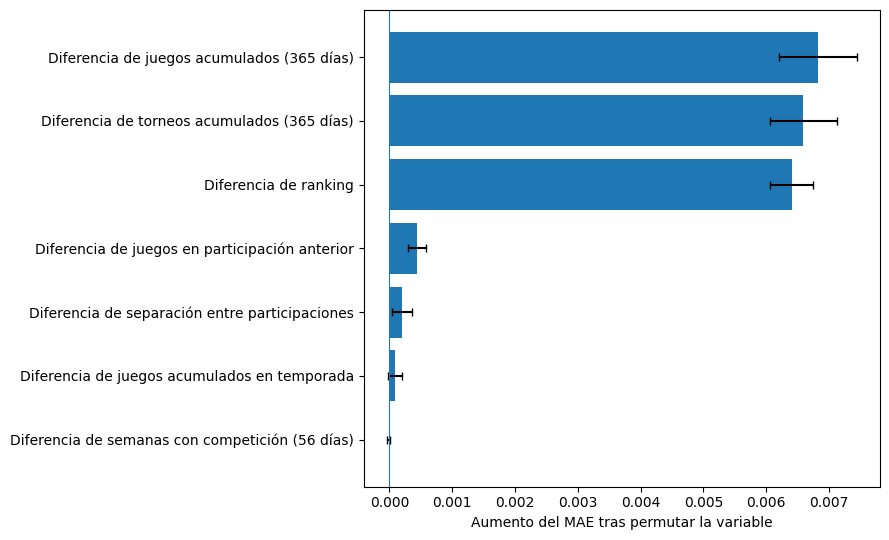

In [17]:
import matplotlib.pyplot as plt

nombres = {
    "diff_juegos_365d": "Diferencia de juegos acumulados (365 días)",
    "diff_torneos_365d": "Diferencia de torneos acumulados (365 días)",
    "diff_ranking": "Diferencia de ranking",
    "diff_juegos_ultima_fecha_competitiva": "Diferencia de juegos en participación anterior",
    "diff_log_dias_entre_inicios_competitivos": "Diferencia de separación entre participaciones",
    "diff_juegos_temporada": "Diferencia de juegos acumulados en temporada",
    "diff_semanas_con_competicion_56d": "Diferencia de semanas con competición (56 días)"
}

figura = (
    importancia_permutacion
    .copy()
    .sort_values("aumento_MAE_medio")
)

figura["nombre"] = figura["variable"].map(nombres)

plt.figure(figsize=(9, 5.5))

plt.barh(
    figura["nombre"],
    figura["aumento_MAE_medio"],
    xerr=figura["desviacion"],
    capsize=3
)

plt.axvline(0, linewidth=0.8)

plt.xlabel("Aumento del MAE tras permutar la variable")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "importancia_permutacion_2024.pdf",
    bbox_inches="tight"
)

plt.show()

## 10. Estabilidad de la mejora según la superficie

La mejora global observada al incorporar variables de carga puede ocultar diferencias entre contextos competitivos.

Como análisis descriptivo de estabilidad, se compara el MAE del modelo BASE y de la especificación AMPLIADA de XGBoost-365d dentro de cada superficie de juego durante la temporada 2024.

Este análisis se realiza después de haber cerrado y evaluado el modelo y no se utiliza para modificar ninguna especificación. Su objetivo es comprobar si la aportación de las variables de carga se concentra exclusivamente en una superficie concreta o mantiene una dirección razonablemente consistente entre contextos.

In [18]:
pred_base_365 = predicciones_finales[
    ("365d", "base", "XGBRegressor")
]

pred_ampliado_365 = predicciones_finales[
    ("365d", "ampliado", "XGBRegressor")
]


df_superficie = df_evaluacion_365d[
    [
        "superficie",
        "_id_partido",
        variable_objetivo
    ]
].copy()

df_superficie["pred_base"] = pred_base_365
df_superficie["pred_ampliado"] = pred_ampliado_365


resultados_superficie = []

for superficie, grupo in df_superficie.groupby("superficie"):

    mae_base = mean_absolute_error(
        grupo[variable_objetivo],
        grupo["pred_base"]
    )

    mae_ampliado = mean_absolute_error(
        grupo[variable_objetivo],
        grupo["pred_ampliado"]
    )

    resultados_superficie.append(
        {
            "superficie": superficie,
            "n_partidos": grupo["_id_partido"].nunique(),
            "MAE_base": mae_base,
            "MAE_ampliado": mae_ampliado,
            "mejora_MAE": mae_base - mae_ampliado
        }
    )


resultados_superficie = pd.DataFrame(
    resultados_superficie
).sort_values(
    "n_partidos",
    ascending=False
)


display(
    resultados_superficie.round(6)
)

,superficie,n_partidos,MAE_base,MAE_ampliado,mejora_MAE
2,Hard,1702,0.100771,0.098798,0.001973
0,Clay,938,0.105170,0.104735,0.000435
1,Grass,316,0.079580,0.078445,0.001135


### Resultado según la superficie

La especificación AMPLIADA presentó un MAE inferior al modelo BASE en las tres superficies analizadas durante 2024.

La mejora fue más elevada en pista dura, seguida de hierba y tierra batida. No obstante, estas diferencias se interpretan de forma descriptiva, especialmente en hierba debido a su menor número de partidos.

En conjunto, los resultados indican que la mejora asociada a la incorporación de variables de carga no se concentra exclusivamente en una superficie determinada, aunque su magnitud varía entre contextos competitivos.

## 11. Exportación de los resultados finales

Una vez completada la evaluación temporal externa y los principales análisis de robustez e interpretabilidad, se exportan los resultados necesarios para garantizar su trazabilidad y facilitar su posterior incorporación a la memoria del TFG.

Se conservan las métricas obtenidas por las distintas especificaciones, los contrastes de mejora del MAE, los resultados del bootstrap pareado, las medidas de importancia del modelo final y las predicciones correspondientes a las especificaciones BASE, PRINCIPAL y AMPLIADA de XGBoost-365d.

La exportación no introduce nuevas decisiones ni modifica los resultados obtenidos. Su finalidad es exclusivamente facilitar la reproducibilidad y conservar de forma estructurada las evidencias utilizadas en las conclusiones del trabajo.

In [19]:
# ============================================================
# 1. MÉTRICAS DE LA EVALUACIÓN EXTERNA FINAL DE 2024
# ============================================================

resultados_evaluacion.to_csv(
    "metricas_evaluacion_final_2024.csv",
    index=False
)


# ============================================================
# 2. CONTRASTES BASE - CARGA
# ============================================================

contrastes_evaluacion.to_csv(
    "contrastes_evaluacion_final_2024.csv",
    index=False
)


# ============================================================
# 3. BOOTSTRAP PAREADO
# ============================================================

resultados_bootstrap.to_csv(
    "bootstrap_evaluacion_final_2024.csv",
    index=False
)


# ============================================================
# 4. INTERPRETABILIDAD DEL MODELO FINAL
# ============================================================

interpretabilidad_final = (
    importancia_variables[
        ["variable", "gain", "posicion_global"]
    ]
    .merge(
        importancia_permutacion[
            [
                "variable",
                "aumento_MAE_medio",
                "desviacion"
            ]
        ],
        on="variable",
        how="left"
    )
)

interpretabilidad_final["es_variable_carga"] = (
    interpretabilidad_final["variable"]
    .isin(variables_carga_365d)
)

interpretabilidad_final.to_csv(
    "interpretabilidad_modelo_final_2024.csv",
    index=False
)


# ============================================================
# 5. PREDICCIONES DEL MODELO PRINCIPAL
# ============================================================

predicciones_exportar = df_evaluacion_365d[
    [
        "_id_partido",
        "fecha_torneo",
        "match_year",
        variable_objetivo
    ]
].copy()

predicciones_exportar["pred_base"] = (
    predicciones_finales[
        ("365d", "base", "XGBRegressor")
    ]
)

predicciones_exportar["pred_principal"] = (
    predicciones_finales[
        ("365d", "principal", "XGBRegressor")
    ]
)

predicciones_exportar["pred_ampliado"] = (
    predicciones_finales[
        ("365d", "ampliado", "XGBRegressor")
    ]
)

predicciones_exportar.to_csv(
    "predicciones_xgb365_final_2024.csv",
    index=False
)


print("Resultados finales exportados correctamente:")
print("- metricas_evaluacion_final_2024.csv")
print("- contrastes_evaluacion_final_2024.csv")
print("- bootstrap_evaluacion_final_2024.csv")
print("- interpretabilidad_modelo_final_2024.csv")
print("- predicciones_xgb365_final_2024.csv")

Resultados finales exportados correctamente:
- metricas_evaluacion_final_2024.csv
- contrastes_evaluacion_final_2024.csv
- bootstrap_evaluacion_final_2024.csv
- interpretabilidad_modelo_final_2024.csv
- predicciones_xgb365_final_2024.csv


## 12. Conclusiones de la evaluación temporal externa

La evaluación sobre la temporada 2024 aportó evidencia favorable sobre la capacidad de generalización temporal del procedimiento desarrollado utilizando exclusivamente las temporadas anteriores.

XGBoost, seleccionado previamente como modelo predictivo principal mediante validación temporal interna, mantuvo un comportamiento competitivo en la evaluación externa. Para la familia de 365 días, la especificación BASE obtuvo un MAE de 0.099902, mientras que la incorporación del núcleo principal de variables de carga redujo el MAE a 0.099051. La especificación AMPLIADA alcanzó un MAE de 0.098506.

En consecuencia, la incorporación conjunta de las variables de carga produjo una reducción aproximada del 1.40 % del MAE respecto al modelo BASE. Esta mejora debe considerarse modesta en términos de magnitud predictiva, pero presentó una elevada consistencia.

La reducción del error se reprodujo con HistGradientBoosting y LightGBM en la familia de 365 días y mantuvo igualmente una dirección favorable al utilizar una ventana de 180 días mediante XGBoost. Por tanto, la conclusión no depende exclusivamente de una arquitectura predictiva ni de un único horizonte temporal.

El bootstrap pareado a nivel de partido respaldó la estabilidad de la mejora observada. Para la comparación BASE–AMPLIADO de XGBoost-365d, el intervalo bootstrap del 95 % de la reducción del MAE se situó completamente por encima de cero. La incorporación adicional de `diff_torneos_365d` también mostró una aportación favorable, aunque menos contundente que la correspondiente al núcleo conjunto de variables de carga.

Los análisis de interpretabilidad mostraron que las distintas dimensiones de carga no presentan la misma relevancia predictiva. `diff_juegos_365d` destacó de forma consistente tanto mediante la importancia interna basada en ganancia como mediante la importancia por permutación realizada respetando las dos observaciones recíprocas de cada partido.

También mostraron una utilización predictiva relevante `diff_torneos_365d`, `diff_juegos_ultima_fecha_competitiva` y `diff_log_dias_entre_inicios_competitivos`, mientras que `diff_juegos_temporada` presentó una contribución menor y `diff_semanas_con_competicion_56d` una importancia marginal prácticamente nula en esta evaluación.

Estas medidas describen la utilización de los predictores por el modelo y no deben interpretarse como estimaciones causales ni como una nueva selección de variables posterior a la evaluación externa.

La mejora BASE–AMPLIADO mantuvo además una dirección favorable en pista dura, tierra batida y hierba, aunque con distinta magnitud entre superficies.

En conjunto, los resultados indican que la carga competitiva previa aporta información predictiva incremental respecto a los predictores tradicionales del partido. Esta aportación es pequeña en magnitud, pero consistente entre periodos, modelos, horizontes temporales y diferentes análisis de robustez.

Debe mantenerse asimismo la limitación metodológica asociada a que parte de la selección exploratoria inicial de predictores se realizó utilizando el conjunto completo de desarrollo. La auditoría temporal posterior mostró que las principales evidencias y decisiones de selección se reproducían de forma estable utilizando únicamente los conjuntos de entrenamiento de cada partición temporal, lo que reduce la preocupación práctica asociada a esta decisión, aunque no elimina formalmente dicha limitación. La temporada 2024 permaneció excluida de esta auditoría y de todas las decisiones previas a la evaluación externa.

El diseño observacional del trabajo no permite concluir que la carga competitiva cause directamente modificaciones en el rendimiento. Una mayor actividad competitiva puede estar relacionada simultáneamente con el nivel del jugador, su continuidad en el circuito, la capacidad para avanzar rondas y otros factores no completamente observados. Por tanto, las conclusiones deben limitarse a asociaciones y capacidad predictiva incremental.